In [1]:
import pandas as pd
import numpy as np

import altair as alt

In [2]:
df = pd.read_csv('fec/totals-2020-01-20T18_57_22.csv')
df['cash'] = df['cash_on_hand_end_period'].apply(lambda x: '${:,d}'.format(int(x)))

In [3]:
# df.info()

In [4]:
df = df.sort_values('cash_on_hand_end_period')

In [5]:
df_contribs_1 = pd.read_csv('fec/contribs_pfluger-berryhill.csv')
df_contribs_2 = pd.read_csv('fec/contribs_cady-schumann.csv')

In [6]:
df_conaway = pd.read_csv('fec/conaway.csv')

In [7]:
frames = [df_contribs_1, df_contribs_2, df_conaway]

In [8]:
df_contribs = pd.concat(frames)

In [9]:
# df_contribs.info()

In [10]:
contribs_grouped = df_contribs.groupby('committee_name').contribution_receipt_amount.sum()

In [11]:
# contribs_grouped.to_csv('fec/contribs_sum.csv', headers=True)

In [12]:
contribs = pd.read_csv('fec/contribs_sum.csv')

In [13]:
merged = pd.merge(df, contribs, on='name')

In [14]:
# merged.head()

In [15]:
totals_2019 = pd.read_csv('fec/totals_2019.csv').rename(columns={'debts_owed_by_committee':'Debt', 'cash_on_hand_end_period':'Cash on hand'})
totals_2019 = totals_2019[totals_2019.name != 'Mike Conaway']

totals_2019 = totals_2019.sort_values('Cash on hand').reset_index(drop=True)
# totals_2019 = totals_2019.drop([11])
totals_2019

,name,receipts,disbursements,Cash on hand,Debt
0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,Brandon Batch,0.00,0.00,0.00,0.00
2,Wesley Virdell,0.00,0.00,0.00,0.00
3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,James Berryhill,0.00,0.00,0.00,0.00
7,Ned Luscombe,0.00,0.00,0.00,0.00
8,Casey Gray,0.00,0.00,0.00,0.00
9,James Faircloth,0.00,0.00,0.00,0.00


In [16]:
# totals_2019 = totals_2019.reset_index(drop=False)
# totals_2019

In [17]:
# totals_2019.level_0 = totals_2019.index * 20
# totals_2019

In [18]:
all_totals = pd.merge(totals_2019, contribs, on='name')
# all_totals.rename(columns={'debts_owed_by_committee':'Debts', 'contributions':'Contributions'})
# all_totals.to_csv('fec/all_totals_2019.csv', header=True)
# all_totals.to_json('fec/all_totals_2019.json', orient='index')

In [19]:
# chart.save('vegachart.html')

In [20]:
json = pd.read_json('fec/all_totals_2019.json')

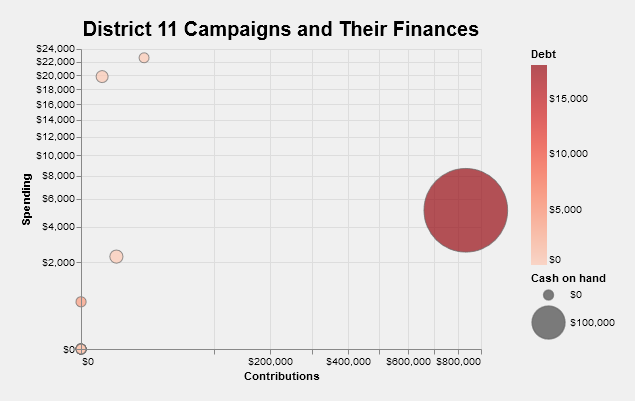

In [21]:
selection = alt.selection_single(on='mouseover', fields=['name','cash_on_hand_end_period', 'contributions'])

# color = alt.condition(selection,
#                      alt.Color('name:N', legend=None),
#                       alt.value('lightgray')
#                      )

def mult_index(number):
    return number * 10

bubble = alt.Chart(all_totals, title='District 11 Campaigns and Their Finances', padding=20).mark_circle(strokeWidth=1, strokeOpacity=1, stroke='#666666').encode(
    alt.X('contributions:Q',
          scale=alt.Scale(zero=False, type='sqrt'),
          sort='ascending',
          title='Contributions',
         axis=alt.Axis(format="$,.0f")
         ),
    alt.Y('disbursements:Q', 
          scale=alt.Scale(zero=False, type='sqrt'),
          sort='ascending', 
          title='Spending',
         axis=alt.Axis(format="$,.0f")
         ),
    alt.Size('Cash on hand:Q',
             scale=alt.Scale(range=[100, 7000]),
            legend=alt.Legend(
#                 direction='horizontal',
                format="$,.0f",
                values=[0,100000],
#                 orient='bottom',
                tickCount=2
            )
            ),
    tooltip=[
        alt.Tooltip(title='Name', field='name', type='ordinal'),
        alt.Tooltip(title='Contributions', field='contributions', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Cash on hand', field='Cash on hand', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Spending', field='disbursements', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Debt', field='Debt', format="$,.0f", type='ordinal')
    ],
    color = alt.Color(
        'Debt:Q',
        scale=alt.Scale(
            scheme='reds'
        ),
        legend=alt.Legend(
            format="$,.0f",
            offset=50
        )
    ),
#     strokeWidth='1:O'
    
).add_selection(
    selection
).configure_axis(
    gridOpacity=0.3,
    gridColor='cornflowerblue',
    domain=False
).configure_view(
    strokeWidth=1,
    stroke='cornflowerblue',
    strokeOpacity=0.3
).configure_scale(
    minSize=100,
    continuousPadding=4,
    maxOpacity=0.9,
    minOpacity=0.4,
    pointPadding=0.3,
).configure_legend(
    offset=100
).configure(
    background='#f0f0f0'
).configure_title(
    fontSize=20
)

bubble

In [22]:
bubble.save('vegabubble.html', embed_options={'actions': False})

## First feedback

Senora Scott, my colleague in journalism, thinks there's too much going on with this chart. Her caveat - that she's not good at reading charts - means this is exactly the kind of feedback I'm looking for. 

This probably means I'm trying to say too much with a single chart. 

Let's play with what the data has for us and see if we can make a set of facet charts while keeping everything within some reasonable constraints:

* We need to limit the height of the bars while still communicating the huge funding lead that Pfluger has over the other candidates. The easiest way to communicate everything is through bar charts, like before.

* We should, therefore, set the colors according to name and set the encoding to `nominal` ... `color=`Name:n`

* I can probably limit the minimum and maximum bar heights using `alt.Scale(100,2000)` or something like that.

* Make sure you set the color scheme to something other than the default.

* Go ahead and rename the columns while you're at it so you don't have to mess around witth changing the titles in each chart.

In [23]:
all_totals = all_totals.rename(columns={'name': 'Name', 'receipts': 'Receipts', 'disbursements': 'Spending', 'Cash on hand': 'Cash on Hand', 'contributions': 'Contributions'})

In [24]:
all_totals

,Name,Receipts,Spending,Cash on Hand,Debt,Contributions
0,Ross Alan Schumann,0.00,0.00,0.00,0.00,0.00
1,Brandon Batch,0.00,0.00,0.00,0.00,0.00
2,Wesley Virdell,0.00,0.00,0.00,0.00,0.00
3,Richard Bartlett,22620.81,22620.81,0.00,0.00,22350.00
4,Wacey Alpha Cody,0.00,0.00,0.00,0.00,0.00
5,Jeffrey Cady,0.00,0.00,0.00,0.00,0.00
6,James Berryhill,0.00,0.00,0.00,0.00,0.00
7,Ned Luscombe,0.00,0.00,0.00,0.00,0.00
8,Casey Gray,0.00,0.00,0.00,0.00,0.00
9,James Faircloth,0.00,0.00,0.00,0.00,0.00


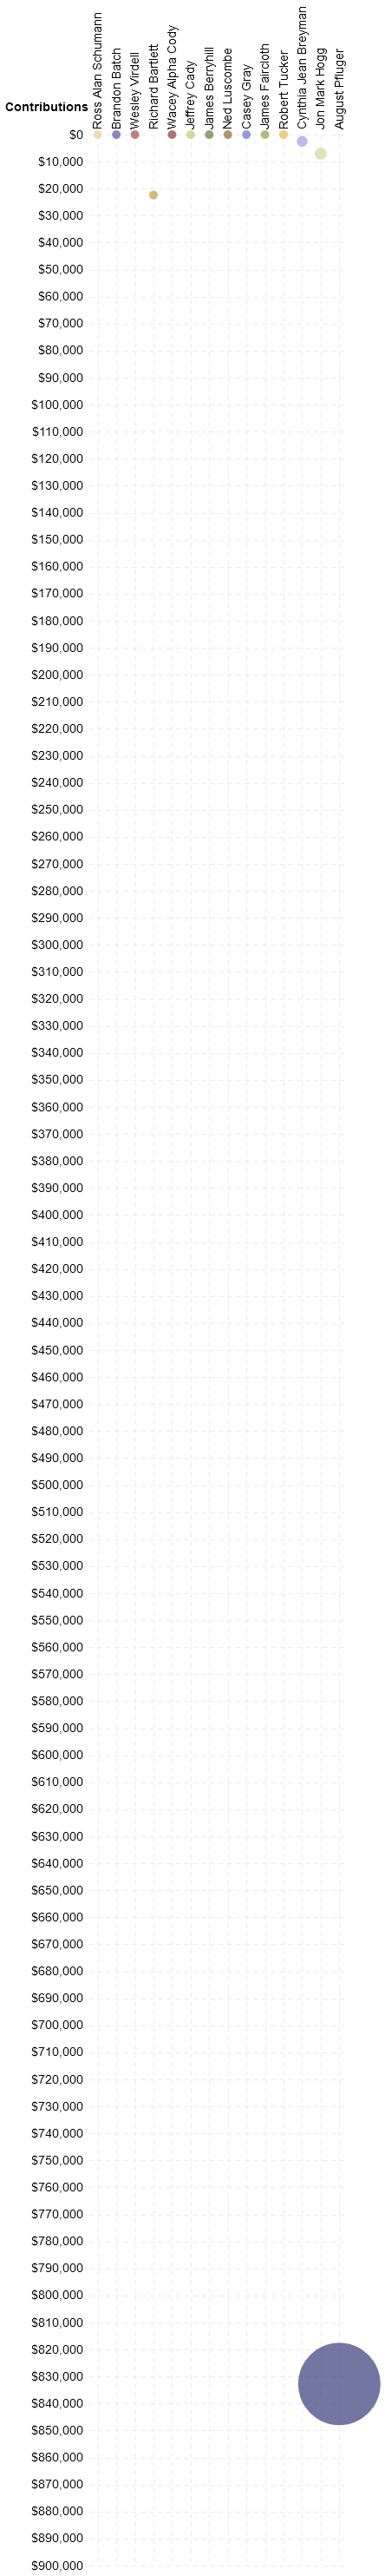

In [25]:
# why not set some reasonable variables?

min_scale = 100
max_scale = 1000
chart_width = 300
chart_height = chart_width / 1.775

bg = '#edebe4'

scheme = 'dark2'

finchart = alt.Chart(all_totals, width=300, height=2800).mark_circle().encode(
    alt.Y('Contributions:Q',
         sort='descending',
          axis=alt.Axis(
              format="$,.0f",
          ),
          scale=alt.Scale(
              range=[2800,0]
          )
         ),
    alt.X('Name:N',
          sort=None,
         axis=alt.Axis(
             orient='top',
             title=None
         )
         ),
    alt.Size('Cash on Hand:Q',
            scale=alt.Scale(
                range=[100, 9000]),
                legend=None
            ),
    color=alt.Color(
        'Name:N',
        legend=None,
        scale=alt.Scale(
            type='linear',
            scheme='category20b'
        )
    ),
    tooltip=[
        alt.Tooltip(title='Name', field='Name', type='ordinal'),
        alt.Tooltip(title='Contributions', field='Contributions', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Cash on hand', field='Cash on Hand', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Spending', field='Spending', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Debt', field='Debt', format="$,.0f", type='ordinal')
    ]
).configure_view(
    strokeWidth=0,
    strokeOpacity=0
).configure_axisTop(
    labelFontSize=14,
    grid=True,
    gridOpacity=0.6,
    gridDash=[5,5],
    tickOpacity=0,
    domainOpacity=0
    
).configure_axisLeft(
    grid=True,
    gridOpacity=0.6,
    gridDash=[5,5],
    labelFontSize=14,
    titleFontSize=14,
    tickOpacity=0,
    titleAnchor='start',
    titleAngle=0,
    titlePadding=20,
    titleBaseline='bottom',
    titleX=-97,
    titleY=-25,
    domainOpacity=0
)

finchart

In [26]:
finchart.save('finchart.html', embed_options={'actions': False})

## Second feedback

I submitted this chart to the nice group at NICAR-L, an email listserv for data journalism. Many good suggestions came my way and all agreed that the above is not the best way to present this data, with one person even questioning the need to present the data at all, which is definitely a good question.

Here's the plan: you need a graphic that can be repeated depending on the race, so we can get an encapsulated idea of where people are in regards to finance.

Also, we need something that communicates where people are getting their money. This wil all be served best by publishing several different charts.

I really need to sit with whatever data is available and figure out what it is I want to show to people who end up on the page.

### Important pieces of information

1. Who's running?

2. How mugh money do they have to campaign?

3. Where, or from whom, did they get that money?

4. What are their positions?
    * Most of the candidates are Republicans or right-leaning Libertarians, how can I compare and contrast their positions?


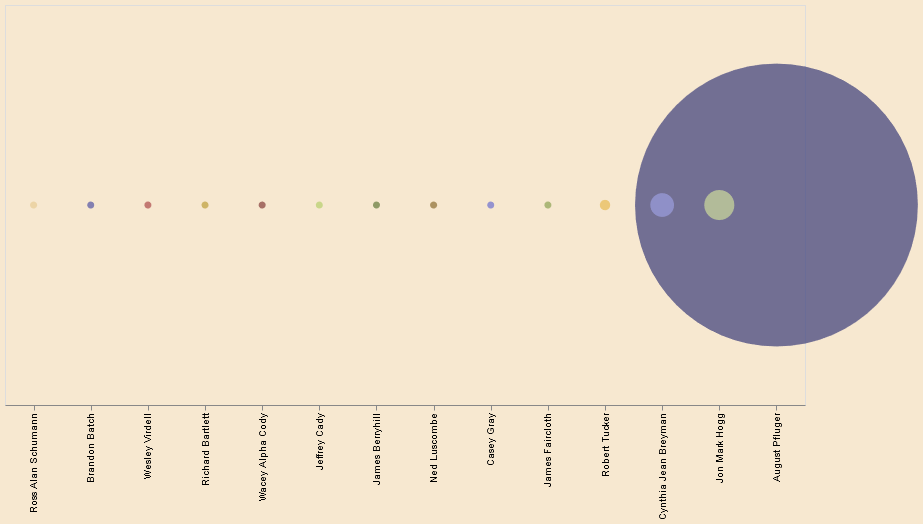

In [79]:
selection = alt.selection_single(on='mouseover')

base_chart = alt.Chart(all_totals, width=800, height=400).mark_circle().add_selection(selection).encode(
    alt.X('Name:N',
          sort=None,
         axis=alt.Axis(
             orient='bottom',
             title=None
         )
         ),
    alt.Size('Cash on Hand:Q',
            scale=alt.Scale(
                range=[50, 80000]),
                legend=None
            ),
    color=alt.Color(
        'Name:N',
        legend=None,
        scale=alt.Scale(
            type='linear',
            scheme='category20b',
        )
    ),
    opacity=alt.condition(selection, alt.value(0.7), alt.value(0.2)),
    order=alt.Order(
        'Cash on Hand',
        sort='descending'
    ),
    tooltip=[
        alt.Tooltip(title='Name', field='Name', type='ordinal'),
        alt.Tooltip(title='Contributions', field='Contributions', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Cash on hand', field='Cash on Hand', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Spending', field='Spending', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Debt', field='Debt', format="$,.0f", type='ordinal')
    ]
).configure_view(
    strokeWidth=0,
    strokeOpacity=0
).configure_axis(
    grid=False
).configure_axisBottom(
    labelFontSize=14,
    grid=False,
    gridOpacity=0.6,
    gridDash=[5,5],
    tickOpacity=0,
    domainOpacity=0    
).configure_axisLeft(
    grid=False,
    gridOpacity=0.6,
    labelFontSize=14,
    titleFontSize=14,
    tickOpacity=0,
    titleAnchor='start',
    titleAngle=0,
    titlePadding=20,
    titleBaseline='bottom',
    titleX=-97,
    titleY=-25,
    domainOpacity=0
).configure_axisTop(
    grid=False
).configure(
    background='#f7e8d0'
).configure_scale(
    bandPaddingInner=0.1,
    bandPaddingOuter=0.8
#     pointPadding=1,
#     round=True
).configure_tick(
    height=50
)

base_chart

In [68]:
base_chart.save(
    'hor_chart.html', 
    embed_options={'actions': False}
)
# base_chart.serve(
#     ip='127.0.0.1',
#     port=8882,
#     open_browser=True
# )

In [ ]:
new_header = json.loc['name']

In [ ]:
json = pd.read_json('fec/all_totals_2019.json')

In [ ]:
json.columns = new_header
json.drop('name', axis=0, inplace=True)

In [ ]:
json.rename(index={
    'cash_on_hand_end_period': 'Cash on Hand',
    'contributions':'Contributions',
    'debts_owed_by_committee': 'Debt',
    'disbursements': 'Spending',
    'receipts':'Receipts'
    },
    inplace=True       
           )

In [ ]:
json

In [ ]:
json.to_html('candidate_table.html', justify='center', table_id='candidate-table-11d')